In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("Accident_train.csv")

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

df.head()

Shape: (10043, 17)

Columns:
Index(['Collision_Ref_No', 'Policing_Area', 'Collision_Severity',
       'Weekday_of_Collision', 'Day_of_Collision', 'Month_of_Collision',
       'Hour_of_Collision', 'Carriageway_Type', 'Speed_Limit',
       'Junction_Detail', 'Junction_Control', 'Ped_Crossing_HC',
       'Ped_Crossing_PC', 'Light_Conditions', 'Weather_Conditions',
       'Road_Surface_Conditions', 'Special_Conditions_at_Site'],
      dtype='object')


,Collision_Ref_No,Policing_Area,Collision_Severity,Weekday_of_Collision,Day_of_Collision,Month_of_Collision,Hour_of_Collision,Carriageway_Type,Speed_Limit,Junction_Detail,Junction_Control,Ped_Crossing_HC,Ped_Crossing_PC,Light_Conditions,Weather_Conditions,Road_Surface_Conditions,Special_Conditions_at_Site
0,3518,CREA,3,MON,4,8,14.0,13,60,1.0,1.0,1.0,1.0,2,9,9.0,1.0
1,10557,BELC,3,SAT,8,8,17.0,11,50,12.0,7.0,1.0,1.0,4,3,1.0,1.0
2,5002,LISB,3,WED,5,11,17.0,1,60,12.0,7.0,1.0,1.0,2,2,2.0,1.0
3,11714,BELC,3,SUN,18,10,16.0,12,70,6.0,NaN,1.0,1.0,1,3,1.0,1.0
4,12416,MIDU,3,MON,23,11,9.0,13,60,6.0,7.0,1.0,1.0,2,3,1.0,1.0


In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10043 entries, 0 to 10042
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Collision_Ref_No            10043 non-null  int64  
 1   Policing_Area               9709 non-null   object 
 2   Collision_Severity          10043 non-null  int64  
 3   Weekday_of_Collision        10043 non-null  object 
 4   Day_of_Collision            10043 non-null  int64  
 5   Month_of_Collision          10043 non-null  int64  
 6   Hour_of_Collision           9759 non-null   float64
 7   Carriageway_Type            10043 non-null  int64  
 8   Speed_Limit                 10043 non-null  int64  
 9   Junction_Detail             9750 non-null   float64
 10  Junction_Control            9744 non-null   float64
 11  Ped_Crossing_HC             9722 non-null   float64
 12  Ped_Crossing_PC             9743 non-null   float64
 13  Light_Conditions            100

In [4]:
print(df.describe(include="all"))

        Collision_Ref_No Policing_Area  Collision_Severity  \
count       10043.000000          9709        10043.000000   
unique               NaN            40                 NaN   
top                  NaN          BELC                 NaN   
freq                 NaN          1256                 NaN   
mean         6565.855720           NaN            2.880613   
std          3928.749772           NaN            0.359226   
min             1.000000           NaN            1.000000   
25%          3060.500000           NaN            3.000000   
50%          7009.000000           NaN            3.000000   
75%         10078.500000           NaN            3.000000   
max         13147.000000           NaN            3.000000   

       Weekday_of_Collision  Day_of_Collision  Month_of_Collision  \
count                 10043      10043.000000        10043.000000   
unique                    7               NaN                 NaN   
top                     FRI               NaN   

In [5]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Collision_Ref_No                0
Policing_Area                 334
Collision_Severity              0
Weekday_of_Collision            0
Day_of_Collision                0
Month_of_Collision              0
Hour_of_Collision             284
Carriageway_Type                0
Speed_Limit                     0
Junction_Detail               293
Junction_Control              299
Ped_Crossing_HC               321
Ped_Crossing_PC               300
Light_Conditions                0
Weather_Conditions              0
Road_Surface_Conditions       309
Special_Conditions_at_Site    288
dtype: int64


In [6]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [7]:
print(df["Collision_Severity"].value_counts())
print(df["Collision_Severity"].value_counts(normalize=True) * 100)

Collision_Severity
3    8964
2     959
1     120
Name: count, dtype: int64
Collision_Severity
3    89.256198
2     9.548940
1     1.194862
Name: proportion, dtype: float64


In [8]:
df = df.drop("Collision_Ref_No", axis=1)

In [9]:
print(df.isnull().sum())

Policing_Area                 334
Collision_Severity              0
Weekday_of_Collision            0
Day_of_Collision                0
Month_of_Collision              0
Hour_of_Collision             284
Carriageway_Type                0
Speed_Limit                     0
Junction_Detail               293
Junction_Control              299
Ped_Crossing_HC               321
Ped_Crossing_PC               300
Light_Conditions                0
Weather_Conditions              0
Road_Surface_Conditions       309
Special_Conditions_at_Site    288
dtype: int64


In [10]:
X = df.drop("Collision_Severity", axis=1)
y = df["Collision_Severity"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10043, 15)
y shape: (10043,)


In [11]:
categorical_columns = X.select_dtypes(include="object").columns.tolist()

numerical_columns = X.select_dtypes(exclude="object").columns.tolist()

print("Categorical columns:")
print(categorical_columns)

print("\nNumerical columns:")
print(numerical_columns)

Categorical columns:
['Policing_Area', 'Weekday_of_Collision']

Numerical columns:
['Day_of_Collision', 'Month_of_Collision', 'Hour_of_Collision', 'Carriageway_Type', 'Speed_Limit', 'Junction_Detail', 'Junction_Control', 'Ped_Crossing_HC', 'Ped_Crossing_PC', 'Light_Conditions', 'Weather_Conditions', 'Road_Surface_Conditions', 'Special_Conditions_at_Site']


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (8034, 15)
Testing data: (2009, 15)


In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_columns),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
    ]
)

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Numerical preprocessing
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine both
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_columns),
    ("cat", categorical_pipeline, categorical_columns)
])

In [16]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

logistic_model.fit(X_train, y_train)

y_pred = logistic_model.predict(X_test)

In [59]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred, average="weighted"))
print("F1 Score :", f1_score(y_test, y_pred, average="weighted"))

Accuracy : 0.8924838227974117
Precision: 0.7965273739550817
Recall   : 0.8924838227974117
F1 Score : 0.841779849697927


C:\Users\NITHIYA SRI G\Downloads\anoconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [60]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [61]:
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred, average="weighted"))
print("Recall   :", recall_score(y_test, rf_pred, average="weighted"))
print("F1 Score :", f1_score(y_test, rf_pred, average="weighted"))

Accuracy : 0.8959681433549029
Precision: 0.8607793019332789
Recall   : 0.8959681433549029
F1 Score : 0.8560430927647741


C:\Users\NITHIYA SRI G\Downloads\anoconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [63]:
from sklearn.tree import DecisionTreeClassifier

dt_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, dt_pred))
print("Precision:", precision_score(y_test, dt_pred, average="weighted"))
print("Recall   :", recall_score(y_test, dt_pred, average="weighted"))
print("F1 Score :", f1_score(y_test, dt_pred, average="weighted"))

Accuracy : 0.8501742160278746
Precision: 0.8540073869268963
Recall   : 0.8501742160278746
F1 Score : 0.8520556634620537


In [64]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, y_pred, average="weighted"),
        precision_score(y_test, dt_pred, average="weighted"),
        precision_score(y_test, rf_pred, average="weighted")
    ],
    "Recall": [
        recall_score(y_test, y_pred, average="weighted"),
        recall_score(y_test, dt_pred, average="weighted"),
        recall_score(y_test, rf_pred, average="weighted")
    ],
    "F1 Score": [
        f1_score(y_test, y_pred, average="weighted"),
        f1_score(y_test, dt_pred, average="weighted"),
        f1_score(y_test, rf_pred, average="weighted")
    ]
})

results

C:\Users\NITHIYA SRI G\Downloads\anoconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\NITHIYA SRI G\Downloads\anoconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.892484,0.796527,0.892484,0.841780
1,Decision Tree,0.850174,0.854007,0.850174,0.852056
2,Random Forest,0.895968,0.860779,0.895968,0.856043


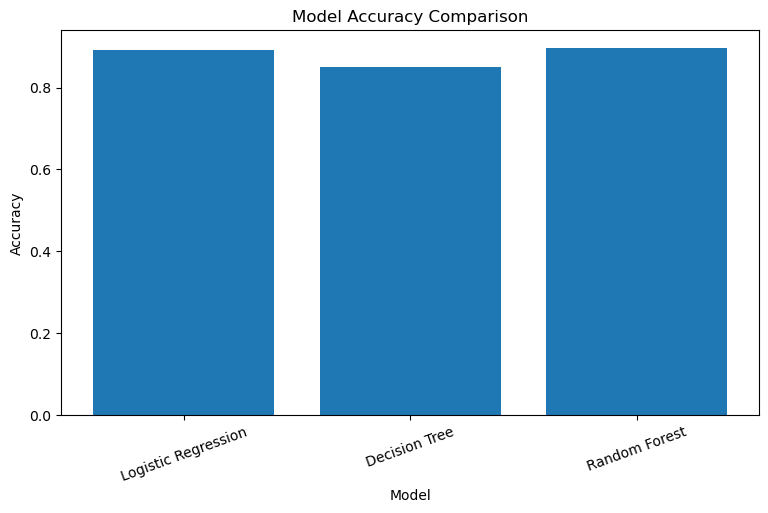

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.bar(results["Model"], results["Accuracy"])

plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=20)

plt.show()

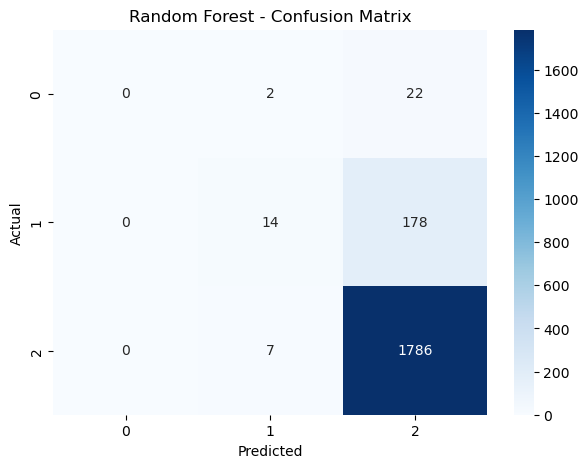

In [66]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest - Confusion Matrix")

plt.show()